
# Complemento numerico: simulacion y diferencias finitas para Black-Scholes

**Complemento practico a la Seccion 3 (Black-Scholes) del TFM, en particular a la Seccion 3.5.**

En el notebook de Higham adaptado (Seccion 2) se uso el articulo de Higham (2001) para implementar Euler-Maruyama y Milstein sobre Ornstein-Uhlenbeck, una SDE que el articulo no trata directamente. Aqui se hace lo mismo pero con la SDE que el propio articulo si trata de forma explicita: en la Seccion 4 de Higham (2001), el ejemplo `em.m` aplica Euler-Maruyama a
$$
dX(t)=\lambda X(t)\,dt+\mu X(t)\,dW(t),
$$
señalando textualmente que *"this SDE arises, for example, as an asset price model in financial mathematics [...] the well-known Black-Scholes partial differential equation can be derived from (4.5)"*. Es, literalmente, el browniano geometrico de la Seccion 3.1 del TFM ($dS_t=\mu S_t\,dt+\sigma S_t\,dW_t$), solo con otros nombres para las constantes.

**Precision importante antes de empezar.** Conviene distinguir con claridad dos pasos que en este notebook aparecen por separado, y que en el notebook anterior (Ornstein-Uhlenbeck) coincidian en uno solo. Euler-Maruyama y Milstein resuelven numericamente la SDE del precio: generan trayectorias simuladas de $S_t$, el comportamiento estocastico del subyacente bajo $Q$. Esto **todavia no es** el precio del derivado. En el notebook de Ornstein-Uhlenbeck, $X_t$ era directamente la cantidad de interes (un tipo de interes, una volatilidad): resolver la SDE era el ultimo paso. Aqui no, resolver la SDE de $S_t$ es solo el primer paso. 

Para llegar al precio de la opcion hace falta un segundo paso:
- Resolver la ecuacion de Black-Scholes (Seccion 3.2 del TFM), ya sea de forma cerrada (Seccion 3.3), numericamente via diferencias finitas (Seccion 4 de este notebook), o de forma equivalente mediante la esperanza descontada del pago (teorema de Feynman-Kac, Seccion 3 de este notebook y Seccion homonima del TFM). Este notebook recorre ambos pasos por separado, precisamente para que esa distincion quede clara.

A diferencia de Ornstein-Uhlenbeck, aqui la difusion $g(S)=\sigma S$ no es cte. Por lo tanto, Milstein (Seccion 6 de Higham) ya no colapsa a Euler-Maruyama. Una vez simulada la trayectoria del subyacente,se usan esas simulaciones para estimar por Monte Carlo el precio de una opcion. Se comparará ese precio frente al que da resolver directamente la EDP con diferencias finitas (Crank-Nicolson, Seccion 3.5) y frente a la formula cerrada (Seccion 3.3).

**Contenidos:**
1. Euler-Maruyama sobre la SDE de Black-Scholes (adaptado de `em.m`, Higham 2001)
2. Milstein sobre la misma SDE
3. De la trayectoria al precio: Monte Carlo
4. Crank-Nicolson (diferencias finitas para la EDP)
5. Comparacion final: Monte Carlo (EM, Milstein) vs. Crank-Nicolson vs. formula cerrada

Se van intercalando comentarios ligeros sobre estabilidad y convergencia donde corresponde, sin entrar en el desarrollo riguroso (queda fuera del alcance de este TFM). Referencias principales: 

- Higham, D.J. (2001), *An Algorithmic Introduction to Numerical Simulation of Stochastic Differential Equations*, SIAM Review;
- Oosterlee, C.W. & Grzelak, L.A. (2019), *Mathematical Modeling and Computation in Finance*.


In [10]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import norm
from scipy.linalg import solve_banded

np.random.seed(42)                          # Reproducibilidad
plt.rcParams['figure.figsize'] = (8, 4.5)
# Estandarizacion del tamaño y estilo de las figuras
plt.rcParams['figure.figsize'] = (8, 4.5)  
mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "legend.fontsize": 9.5,
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.6,
    "axes.edgecolor": "#333333",
    "axes.linewidth": 0.8,
    "figure.dpi": 150,
})


In [11]:
def bs_call(S, K, r, sigma, tau):
    """Formula cerrada de Black-Scholes (Seccion 3.3) para una call europea."""
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    d2 = d1 - sigma * np.sqrt(tau)
    return S * norm.cdf(d1) - K * np.exp(-r * tau) * norm.cdf(d2)

# Parametros de la opcion, comunes a todo el notebook
S0 = 100
K = 100
r = 0.05
sigma = 0.2
T = 1.0


## 1. Euler-Maruyama sobre la SDE de Black-Scholes

Adaptando `em.m` (Higham 2001) a la notacion financiera del TFM, la SDE es $dS_t=rS_t\,dt+\sigma S_t\,dW_t$ (Seccion 3.1, ya bajo la medida neutral al riesgo, Seccion 4.1: el drift es $r$ y no $\mu$). Euler-Maruyama discretiza:
$$
S_j = S_{j-1} + rS_{j-1}\,\Delta t + \sigma S_{j-1}\,\Delta W_j.
$$
Como en el articulo, se compara frente a la solucion exacta (Seccion 3.1 del TFM, la misma SDE lineal ya vista):
$$
S_t = S_0\exp\!\left[\left(r-\tfrac12\sigma^2\right)t+\sigma W_t\right],
$$
usando la misma trayectoria browniana para ambas, y tomando un paso de simulacion de Euler-Maruyama, $\Delta t=R\,\delta t$, mas grueso que el paso $\delta t$ con el que se genero el browniano.


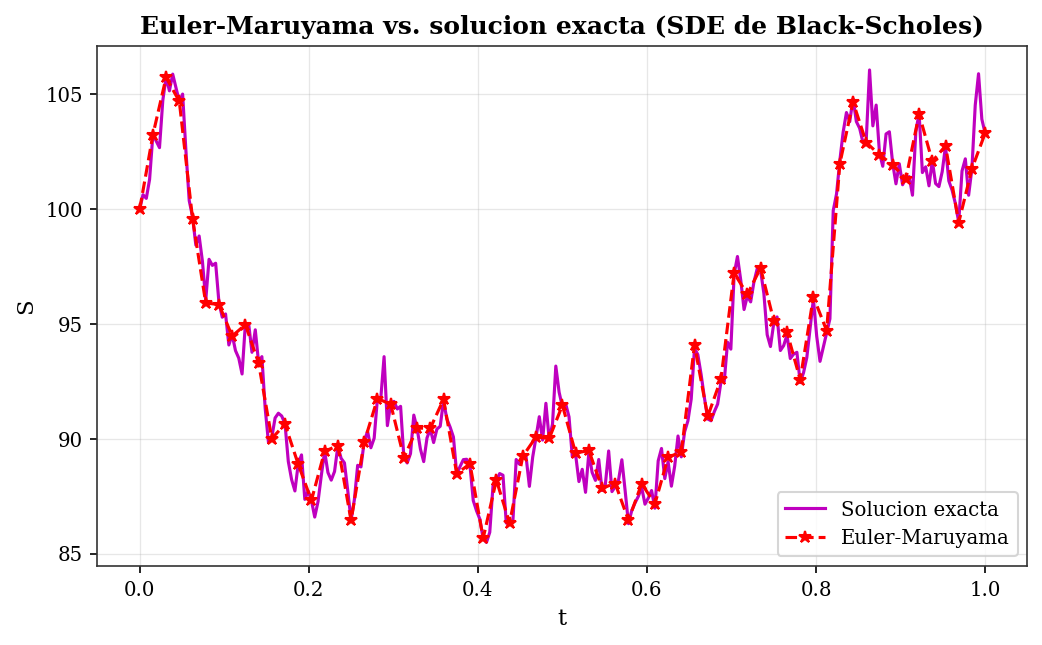

Error en el punto final (t=T): 0.0048


In [ ]:

# Discretizacion del browniano
N = 2**8
dt = T / N
dW = np.sqrt(dt) * np.random.randn(N)
W = np.cumsum(dW)

t_fine = np.linspace(dt, T, N)
S_exacta = S0 * np.exp((r - 0.5 * sigma**2) * t_fine + sigma*W)

# Euler-Maruyama con paso mas grueso Delta t = R*dt 
R = 4
Dt = R * dt
L = N // R

S_em = np.zeros(L)
S_temp = S0
for j in range(L):
    W_inc = np.sum(dW[R*j:R*(j+1)])              # incremento acumulado en el paso grueso
    S_temp = S_temp + Dt*r*S_temp + sigma*S_temp*W_inc
    S_em[j] = S_temp

##################################
##################################
################################## Representaciones
plt.plot(np.concatenate(([0], t_fine)), np.concatenate(([S0], S_exacta)), 'm-', label='Solucion exacta')
t_em = np.linspace(0, T, L + 1)
plt.plot(t_em, np.concatenate(([S0], S_em)), 'r--*', label='Euler-Maruyama')
plt.xlabel('t'); plt.ylabel('S')
plt.legend(); plt.grid(alpha=0.3)
plt.title('Euler-Maruyama vs. solucion exacta (SDE de Black-Scholes)')
plt.show()

print(f"Error en el punto final (t=T): {abs(S_em[-1] - S_exacta[-1]):.4f}")



**Nota ligera sobre convergencia y estabilidad.** Higham (2001, Seccion 5) muestra que Euler-Maruyama converge con orden fuerte $\gamma=1/2$ (frente al orden 1 del Euler determinista). Es decir, el error tipico decrece solo con $\sqrt{\Delta t}$, no con $\Delta t$. Ademas (Seccion 7 del articulo), la estabilidad de Euler-Maruyama sobre esta misma SDE depende de $\Delta t$: para que el segundo momento no explote hace falta $|1+\Delta t\,r|^2+\Delta t\,\sigma^2<1$, una condicion mas estricta que la puramente determinista. No se profundiza mas en ninguno de los dos puntos (queda fuera del alcance de este TFM); baste con la idea de que "más barato" no es gratis.


## 2. Milstein sobre la misma SDE

La formula general de Milstein (Higham 2001, ecuacion 6.1) es
$$
X_j = X_{j-1} + \Delta t\,f(X_{j-1}) + g(X_{j-1})\,\Delta W_j + \tfrac12\,g(X_{j-1})g'(X_{j-1})\big[(\Delta W_j)^2-\Delta t\big].
$$
En el articulo, Milstein se ilustra sobre una SDE de dinamica poblacional (`milstrong.m`), no sobre la SDE de Black-Scholes -- aqui se adapta directamente a esta ultima, igual que ya se adapto a Ornstein-Uhlenbeck en el notebook anterior. La diferencia importante es que ahora si cambia algo: con $g(S)=\sigma S$, la derivada es $g'(S)=\sigma\neq0$ (constante, pero no nula), asi que el termino de correccion no se anula:
$$
S_j = S_{j-1} + rS_{j-1}\Delta t + \sigma S_{j-1}\Delta W_j + \tfrac12\sigma^2S_{j-1}\big[(\Delta W_j)^2-\Delta t\big].
$$


/tmp/ipykernel_49782/2661827877.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


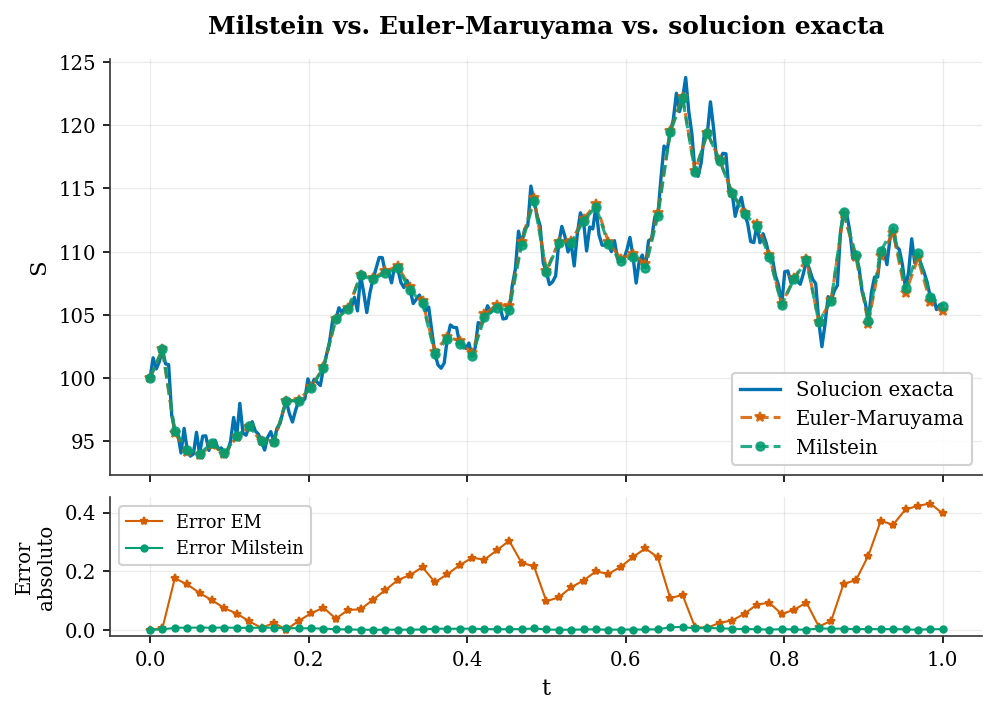

Error en el punto final -- Euler-Maruyama: 0.3969
Error en el punto final -- Milstein       : 0.0022


In [ ]:
# Discretizacion fina del browniano
N = 2**8
dt = T / N
dW = np.sqrt(dt) * np.random.randn(N)
W = np.cumsum(dW)

t_fine = np.linspace(dt, T, N)
S_exacta = S0 * np.exp((r - 0.5 * sigma**2) * t_fine + sigma * W)

# Euler-Maruyama con paso mas grueso Delta t = R*dt 
R = 4
Dt = R * dt
L = N // R

S_em = np.zeros(L)
S_temp = S0
for j in range(L):
    W_inc = np.sum(dW[R*j:R*(j+1)])
    S_temp = S_temp + Dt*r*S_temp + sigma*S_temp*W_inc
    S_em[j] = S_temp
t_em = np.linspace(0, T, L + 1)

# Milstein, mismo browniano y mismo paso grueso que Euler-Maruyama, para comparar en igualdad de condiciones
S_mil = np.zeros(L)
S_temp = S0
for j in range(L):
    W_inc = np.sum(dW[R*j:R*(j+1)])
    S_temp = (S_temp + Dt*r*S_temp + sigma*S_temp*W_inc
              + 0.5*sigma**2 * S_temp * (W_inc**2 - Dt))
    S_mil[j] = S_temp

# Error absoluto frente a la solucion exacta
S_exacta_full = np.concatenate(([S0], S_exacta))
S_exacta_gruesa = S_exacta_full[::R]
error_em = np.abs(np.concatenate(([S0], S_em)) - S_exacta_gruesa)
error_mil = np.abs(np.concatenate(([S0], S_mil)) - S_exacta_gruesa)



##################################
##################################
################################## Representaciones
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7.5, 5), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.08})

# Paths
ax1.plot(np.concatenate(([0], t_fine)), np.concatenate(([S0], S_exacta)),
         color='#0072B2', linewidth=1.6, zorder=2, label='Solucion exacta')
ax1.plot(t_em, np.concatenate(([S0], S_em)),
         color='#D55E00', linestyle='--', marker='*', markersize=5, alpha=0.85, zorder=3, label='Euler-Maruyama')
ax1.plot(t_em, np.concatenate(([S0], S_mil)),
         color='#009E73', linestyle='--', marker='o', markersize=4, alpha=0.85, zorder=4, label='Milstein')
ax1.set_ylabel('S')
ax1.set_title('Milstein vs. Euler-Maruyama vs. solucion exacta', pad=12)
ax1.legend(loc='lower right', framealpha=0.9)
ax1.grid(alpha=0.25)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Errores
ax2.plot(t_em, error_em, color='#D55E00', linewidth=1, marker='*', markersize=4, label='Error EM')
ax2.plot(t_em, error_mil, color='#009E73', linewidth=1, marker='o', markersize=3, label='Error Milstein')
ax2.set_xlabel('t')
ax2.set_ylabel('Error\nabsoluto', fontsize=9.5)
ax2.legend(loc='upper left', fontsize=8.5, framealpha=0.9)
ax2.grid(alpha=0.25)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

fig.tight_layout()
#fig.savefig('bs_em_milstein.pdf', bbox_inches='tight')
plt.show()

print(f"Error en el punto final -- Euler-Maruyama: {abs(S_em[-1] - S_exacta[-1]):.4f}")
print(f"Error en el punto final -- Milstein       : {abs(S_mil[-1] - S_exacta[-1]):.4f}")


**Nota ligera sobre convergencia.** Higham (2001, Seccion 6) muestra que este termino de correccion eleva el orden fuerte de convergencia de $1/2$ a $1$ -- Milstein converge, en promedio, tan rapido como el Euler determinista. Con una unica trayectoria (como aqui) el error puntual puede no reflejar bien esa mejora de orden -- para verla con claridad haria falta repetir el experimento sobre muchas trayectorias y promediar, como hace el propio Higham en `milstrong.m` -- pero el termino de correccion ya esta ahi, listo para cuando haga falta mas precision sin reducir el paso.



## 3. De la trayectoria al precio: Monte Carlo

Ya hemos visto como una trayectoria simulada de $S_t$ no es, todavia, un precio. La via estandar que se sigue en el TFM (Secciones 3.2-3.3) para dar ese segundo paso es resolver directamente la ecuacion de Black-Scholes: la EDP derivada mediante el argumento de cartera replicante y cobertura dinamica. Ya sea de forma cerrada (formula de Black-Scholes) o, como se hace mas abajo (Seccion 4 de este notebook), mediante diferencias finitas.

Existe, sin embargo, una via alternativa y equivalente para llegar al mismo precio, que es la que se usa en esta seccion: el teorema de **Feynman-Kac** (Seccion homonima del TFM) permite reescribir la solucion de esa misma EDP como una esperanza descontada del pago bajo la medida neutral al riesgo $Q$:

$$
V(S_0,0) = e^{-rT}\,\mathbb E^Q\big[\max(S_T-K,0)\big].
$$

Como Euler-Maruyama y Milstein ya generan trayectorias de $S_t$ bajo $Q$ (el drift usado es $r$), calcular esta esperanza es inmediato: basta con simular muchas trayectorias, evaluar el pago en $T$, descontar, y promediar.

Conviene subrayar el papel de esta seccion dentro del TFM: Feynman-Kac se presenta mas adelante como la herramienta central para resolver el modelo de Heston, donde no hay formula cerrada disponible. Aqui, en Black-Scholes, la formula cerrada si existe, asi que Feynman-Kac no es estrictamente necesario. Simplemente nos sirve como primer ejemplo de uso del teorema, de forma mas sencilla y ya validada contra la formula cerrada.


In [ ]:

# Monte Carlo: mismo esquema, vectorizado sobre M trayectorias simultaneas
M = 50_000
N_mc = 252                    # pasos de simulacion 
dt_mc = T / N_mc

dW_mc = np.sqrt(dt_mc) * np.random.randn(M, N_mc)

#  Euler-Maruyama 
S_em_mc = np.full(M, S0, dtype=float)
for j in range(N_mc):
    S_em_mc = S_em_mc + r*S_em_mc*dt_mc + sigma*S_em_mc*dW_mc[:, j]

precio_em = np.exp(-r*T) * np.mean(np.maximum(S_em_mc - K, 0))

#  Milstein 
S_mil_mc = np.full(M, S0, dtype=float)
for j in range(N_mc):
    Winc = dW_mc[:, j]
    S_mil_mc = (S_mil_mc + r*S_mil_mc*dt_mc + sigma*S_mil_mc*Winc
                + 0.5*sigma**2 * S_mil_mc * (Winc**2 - dt_mc))

precio_mil = np.exp(-r * T) * np.mean(np.maximum(S_mil_mc - K, 0))

precio_cerrado_S0 = bs_call(S0, K, r, sigma, T)

print(f"Precio Monte Carlo (Euler-Maruyama): {precio_em:.4f}")
print(f"Precio Monte Carlo (Milstein)      : {precio_mil:.4f}")
print(f"Precio formula cerrada (Seccion 3.3): {precio_cerrado_S0:.4f}")


Precio Monte Carlo (Euler-Maruyama): 10.3344
Precio Monte Carlo (Milstein)      : 10.3331
Precio formula cerrada (Seccion 3.3): 10.4506



Los dos precios Monte Carlo deberian parecerse mucho entre si y a la formula cerradacon $M=50\,000$ trayectorias, el error dominante ya no es el esquema de discretizacion (EM vs. Milstein), sino el propio error de muestreo Monte Carlo, que decae como $1/\sqrt M$ independientemente del esquema usado (Higham, Seccion 5, lo señala tambien al hablar de fuentes de error). 

Es decir, aqui Milstein no se nota tanto como en la Seccion 2 porque el ruido de muestreo tapa la ganancia de orden (para que se notase claramente haria falta reducir $M$ o comparar con muchas menos trayectorias y muchas repeticiones).



## 4. Crank-Nicolson (diferencias finitas para la EDP)

La via Monte Carlo de la Seccion 3 tiene un problema practico: para cada strike, vencimiento o punto de la superficie de precios hay que repetir toda la simulacion. La alternativa (Seccion 3.5 del TFM) es resolver directamente la EDP de Black-Scholes (Seccion 3.2),
$$
\frac{\partial V}{\partial t} + \frac12\sigma^2 S^2\frac{\partial^2 V}{\partial S^2} + rS\frac{\partial V}{\partial S} - rV = 0, \qquad V(S,T)=\max(S-K,0),
$$
sobre una malla $(S_i,t_j)$, con diferencias centradas en $S$. 

Antes de seguir: la teoria de diferencias finitas (consistencia, estabilidad, convergencia de cada esquema) es un campo extenso, con libros enteros dedicados solo a eso (el propio Oosterlee \& Grzelak, 2019, le dedica varios capitulos). Aqui no se pretende desarrollar esa teoria, solo aplicarla al caso concreto de Black-Scholes, con las ideas minimas para justificar por que se elige Crank-Nicolson. Habitualmetne se contemplan tres variantes
- Explicita
- Implicita
- Crank-Nicolson 
Se diferencian solo en el instante en que se evaluan las derivadas espaciales (conocido, desconocido, o un promedio de ambos). Aqui se implementa directamente **Crank-Nicolson**, que promedia explicito e implicito y es la que el TFM usa como referencia principal.
---
Siguiendo a Oosterlee & Grzelak (2019), que tratan este mismo esquema en el contexto del *method of lines*, reduciendo primero la EDP a un sistema de EDOs en $S$ discreto, $d\mathbf V/dt=A\mathbf V$, antes de aplicar un integrador temporal. Crank-Nicolson corresponde a la regla del trapecio aplicada a ese sistema:
$$
\Big(I-\tfrac12\Delta t\,A\Big)\mathbf V^{j} = \Big(I+\tfrac12\Delta t\,A\Big)\mathbf V^{j+1}.
$$
Esto exige resolver un sistema tridiagonal en cada paso (como el esquema implicito puro), pero a cambio se gana **precision de segundo orden en el tiempo** ( frente al primer orden de explicito/implicito puros), ademas de heredar la estabilidad incondicional del implicito. Es, en espiritu, la misma idea que llevaba a Milstein a mejorar sobre Euler-Maruyama en la Seccion 2: promediar (o corregir) para ganar un orden de precision sin reducir el paso.


In [ ]:
# Parametros de la malla (Smax y M elegidos para que S0=100 caiga justo en un nodo)
M_grid = 150
N_grid = 1000
Smax = 3 * K
Sgrid = np.linspace(0, Smax, M_grid + 1)
dt_grid = T / N_grid

def bs_crank_nicolson(S, K, r, sigma, T, M, N):
    dt = T / N
    i = np.arange(1, M)

    A = 0.5 *(sigma**2 * i**2 - r * i)
    B = -(sigma**2 * i**2 + r)
    C = 0.5 * (sigma**2 * i**2 + r * i)

    p, q, s    = -0.5*dt*A, 1 - 0.5*dt*B, -0.5*dt*C   # lado desconocido (t_j)
    p2, q2, s2 =  0.5*dt*A, 1 + 0.5*dt*B,  0.5*dt*C   # lado conocido   (t_{j+1})

    banda = np.zeros((3, M - 1))
    banda[0,1:]  = s[:-1]
    banda[1,:]   = q
    banda[2,:-1] = p[1:]

    V = np.maximum(S - K, 0)

    for j in range(N):
        tau_old = j*dt
        tau_new = (j+1)*dt
        bound_old = S[-1] - K*np.exp(-r*tau_old)
        bound_new = S[-1] - K*np.exp(-r*tau_new)

        Vm1 = np.concatenate(([0.0], V[1:M-1]))
        Vi  = V[1:M]
        Vp1 = np.concatenate((V[2:M], [bound_old]))

        rhs = p2*Vm1 + q2*Vi + s2*Vp1
        rhs[-1] -= s[-1] * bound_new

        V_interior = solve_banded((1, 1), banda, rhs)
        V = np.concatenate(([0.0], V_interior, [bound_new]))

    return V

V_cn = bs_crank_nicolson(Sgrid, K, r, sigma, T, M_grid, N_grid)

indice_S0 = np.searchsorted(Sgrid, S0)          # S0=100 cae exacto en un nodo con este M
precio_cn = V_cn[indice_S0]
print(f"Precio Crank-Nicolson: {precio_cn:.4f}")


Precio Crank-Nicolson: 10.4407



**Nota sobre estabilidad.** Que un esquema sea *estable* significa, en terminos simples, que los pequenos errores de redondeo o de discretizacion que aparecen en cada paso no se amplifican sin control a medida que se avanza en el tiempo, es decir, se mantienen acotados. Un esquema *inestable*, en cambio, puede hacer que esos errores crezcan exponencialmente paso a paso, hasta que la solucion numerica deja de parecerse en nada a la solucion real (valores que explotan, oscilan sin sentido, o se disparan a infinito), incluso si el paso de tiempo $\Delta t$ es razonablemente pequeno.

En el esquema explicito de Euler-Maruyama (Seccion 1) esto se traducia en que la estabilidad exigia mantener $\Delta t$ por debajo de un cierto umbral (Higham, 2001, Seccion 7). Crank-Nicolson, en cambio, es **incondicionalmente estable**: para cualquier $\Delta t$ y $\Delta S$, los errores no se amplifican (Oosterlee \& Grzelak, 2019). Esto no quiere decir que el resultado sea igual de preciso con cualquier paso: un $\Delta t$ grande sigue dando una solucion menos exacta, simplemente ya no diverge. Es la misma distincion entre estabilidad y precision que ya aparecio con Euler-Maruyama, solo que aqui queda resuelta por la propia estructura del esquema, no por reducir el paso a la fuerza.



## 5. Comparacion final

Tres caminos distintos para llegar (idealmente) al mismo numero: simular el subyacente con Euler-Maruyama y promediar pagos, simular con Milstein y promediar pagos, o resolver directamente la EDP con Crank-Nicolson. Los tres se contrastan contra la formula cerrada (Seccion 3.3), que aqui hace de arbitro.


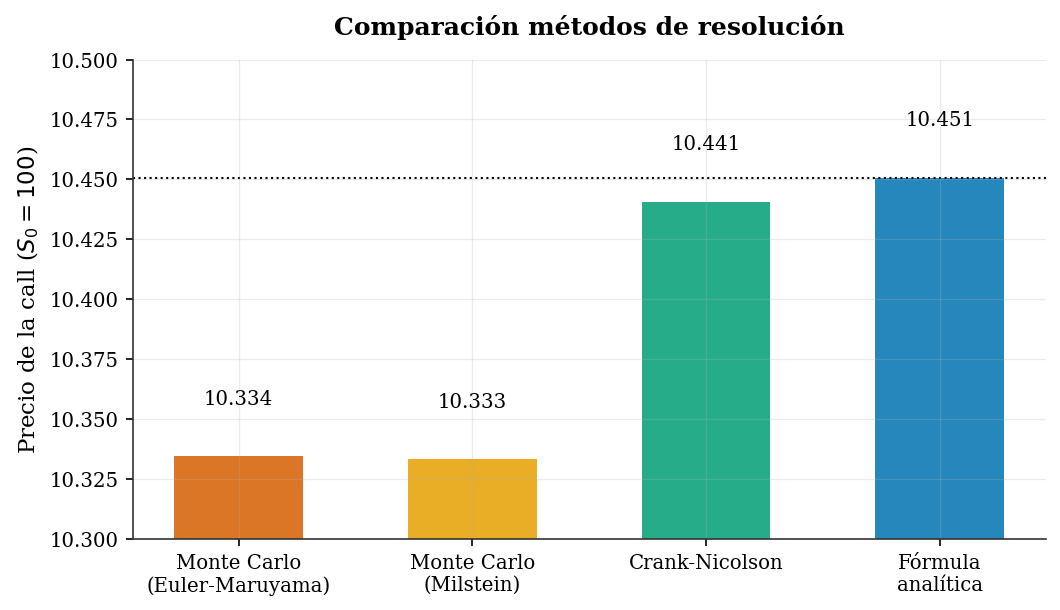

Monte Carlo (Euler-Maruyama): 10.3344   (error vs. formula analítica: 0.1162)
Monte Carlo (Milstein): 10.3331   (error vs. formula analítica: 0.1175)
Crank-Nicolson: 10.4407   (error vs. formula analítica: 0.0099)
Fórmula analítica: 10.4506   (error vs. formula analítica: 0.0000)


In [16]:
metodos = ['Monte Carlo\n(Euler-Maruyama)', 'Monte Carlo\n(Milstein)', 'Crank-Nicolson', 'Fórmula\nanalítica']
precios = [precio_em, precio_mil, precio_cn, precio_cerrado_S0]
colores = ['#D55E00', '#E69F00', '#009E73', '#0072B2']

fig, ax = plt.subplots(figsize=(7.2, 4.2))
bars = ax.bar(metodos, precios, color=colores, alpha=0.85, width=0.55)
ax.axhline(precio_cerrado_S0, color='k', linestyle=':', linewidth=1, zorder=1)

ax.set_ylim(10.3, 10.5)
for b, p in zip(bars, precios):
    ax.text(b.get_x() + b.get_width()/2, p + 0.02, f'{p:.3f}',
            ha='center', va='bottom', fontsize=9.5)

ax.set_ylabel(f'Precio de la call ($S_0={S0}$)')
ax.set_title('Comparación métodos de resolución', pad=12)
ax.grid(alpha=0.25, axis='y')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.tight_layout()
fig.savefig('bs_comparacion_metodos.pdf', bbox_inches='tight')
fig.savefig('bs_comparacion_metodos.png', bbox_inches='tight', dpi=220)
plt.show()

# Soluciones y errores
for nombre, precio in zip(metodos, precios):
    error = abs(precio - precio_cerrado_S0)
    print(f"{nombre.replace(chr(10), ' ')}: {precio:.4f}   (error vs. formula analítica: {error:.4f})")


### Conclusion practica

Los tres metodos coinciden con la formula cerrada dentro de un margen razonable, lo que valida tanto la via estocastica (Euler-Maruyama/Milstein + Monte Carlo) como la via determinista (Crank-Nicolson) antes de usarlas como referencia frente a Heston (Seccion 5 del TFM). En terminos practicos, cada via tiene su sitio: Monte Carlo es la que se generaliza sin esfuerzo a productos con pagos complicados o a mas fuentes de aleatoriedad (como el propio Heston, Seccion 5), mientras que Crank-Nicolson da toda la superficie de precios $V(S,t)$ de una sola pasada, mucho mas rapido cuando basta con precios europeos estandar sobre una sola SDE.

**Referencias de este notebook:** Higham, D.J. (2001), *An Algorithmic Introduction to Numerical Simulation of Stochastic Differential Equations*, SIAM Review, 43(3), 525-546; Oosterlee, C.W. & Grzelak, L.A. (2019), *Mathematical Modeling and Computation in Finance*, World Scientific.
